es 1.1

In [1]:
x = 1.0
while (1+x > 1):
    x = x / 2
print(x)

1.1102230246251565e-16


controllo ma dovrebbe essere la machine epsilon corretta

es 1.2

In [2]:
import numpy as np
a = 1.0
b = np.power(10, 8)
c = 1.0

def naive_quaddratic(a, b, c):
    x = np.zeros(2)
    x[1] = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
    x[0] = (-b - np.sqrt(b**2 - 4*a*c)) / (2*a)
    return x    
    return (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)

def stable_quadratic(a, b, c):
    x = np.zeros(2)
    if b > 0:
        x[0] = (-b - np.sqrt(b**2 - 4*a*c)) / (2*a)
    else:
        x[0] = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
    x[1] = c / (a*x[0])
    return x

x_naive = naive_quaddratic(a, b, c)
x_stable = stable_quadratic(a, b, c)
print("Naive quadratic formula: ", x_naive)
print("Stable quadratic formula: ", x_stable)

Naive quadratic formula:  [-1.0000000e+08 -7.4505806e-09]
Stable quadratic formula:  [-1.e+08 -1.e-08]


la formula naive ha una catastrofic cancellation per uno dei due risultati. ora comparo gli errori relativi dei due risultati con il risultato esatto ( preso da wolfram alpha:)

In [3]:
x_true = np.array([-9.99999999999999899999999999999989999999999999997999999999999999499999999999999859999999999999957999999999999986800*10**7 ,-1.000000000000000100000000000000020000000000000005000000000000001400000000000000420000000000000132000000000000042900*10**(-8)])

rel_error_naive = np.abs(x_naive - x_true) / np.abs(x_true)
rel_error_stable = np.abs(x_stable - x_true) / np.abs(x_true)

print("Relative error of naive quadratic formula: ", rel_error_naive)
print("Relative error of stable quadratic formula: ", rel_error_stable)

Relative error of naive quadratic formula:  [1.49011612e-16 2.54941940e-01]
Relative error of stable quadratic formula:  [1.49011612e-16 0.00000000e+00]


es 1.3

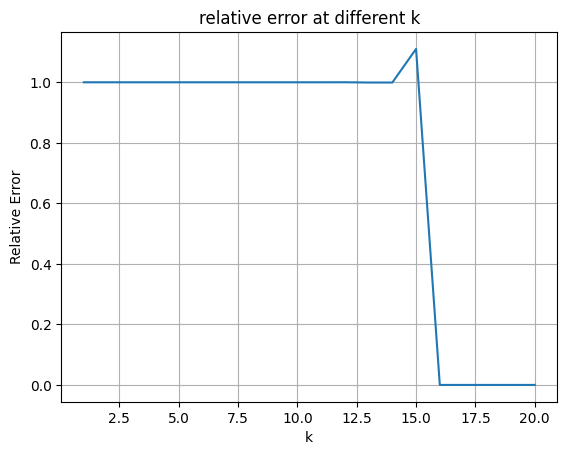

In [4]:
import matplotlib.pyplot as plt
def f(k):
    return 1 + 10**(-k)

f_values = np.zeros(20)
rel_errors = np.zeros(20)
y = 1
for k in range(1, 20):
    f_values[k-1] = f(k)
    rel_errors[k-1] = np.abs(f_values[k-1] - y)/(10**(-k))

x = np.linspace(1, 20, 20)
plt.plot(x, rel_errors)
plt.xlabel('k')
plt.ylabel('Relative Error')
plt.title('relative error at different k')
plt.grid()
plt.show()


capisco che è uno e che poi diventa 0, non capisco troppo la parte dove aumenta, vediamo di specificarlo:

In [5]:
print(f_values)
for i in range(20):
    print(10**(-i))
print(rel_errors)



[1.1        1.01       1.001      1.0001     1.00001    1.000001
 1.0000001  1.00000001 1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.        ]
1
0.1
0.01
0.001
0.0001
1e-05
1e-06
1e-07
1e-08
1e-09
1e-10
1e-11
1e-12
1e-13
1e-14
1e-15
1e-16
1e-17
1e-18
1e-19
[1.         1.         1.         1.         1.         1.
 1.         0.99999999 1.00000008 1.00000008 1.00000008 1.0000889
 0.99920072 0.99920072 1.11022302 0.         0.         0.
 0.         0.        ]


ok così si capisce di più dai.

es 1.4

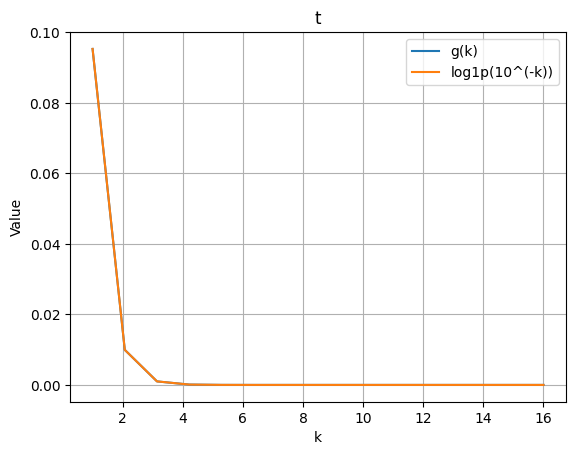

In [10]:
def g(k):
    return np.log(1+ 10**(-k))

g_values = np.zeros(15)
g_best = np.zeros(15)
for k in range(1, 16):
    g_values[k-1] = g(k)
    g_best[k-1] = np.log1p(10**(-k))

x = np.linspace(1, 16, 15)
plt.plot(x, g_values, label='g(k)')
plt.plot(x, g_best, label='log1p(10^(-k))')
plt.xlabel('k')
plt.ylabel('Value')
plt.title('t')
plt.legend()
plt.grid()
plt.show()



lo finisco dopo 